In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [2]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

In [5]:
apps.head()
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [7]:
apps.info()

apps.describe()

apps.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [8]:
apps.drop_duplicates(inplace=True)

In [9]:
apps.dropna(inplace=True)

In [10]:
apps['Reviews'] = apps['Reviews'].astype(int)

In [11]:
apps['Installs'] = apps['Installs'].str.replace('+','')
apps['Installs'] = apps['Installs'].str.replace(',','')
apps['Installs'] = apps['Installs'].astype(int)

In [12]:
apps['Price'] = apps['Price'].str.replace('$','')
apps['Price'] = apps['Price'].astype(float)

In [17]:
import numpy as np
import pandas as pd

def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == 'Varies with device':
        return np.nan
    elif 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1000
    else:
        return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

In [18]:
apps['Size'] = pd.to_numeric(apps['Size'], errors='coerce')

In [19]:
apps = pd.read_csv("apps.csv")

In [20]:
print(apps['Size'].dtype)
print(apps['Size'].head(10))

float64
0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
5     5.6
6    19.0
7    29.0
8    33.0
9     3.1
Name: Size, dtype: float64


In [21]:
apps['Category'].value_counts()

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


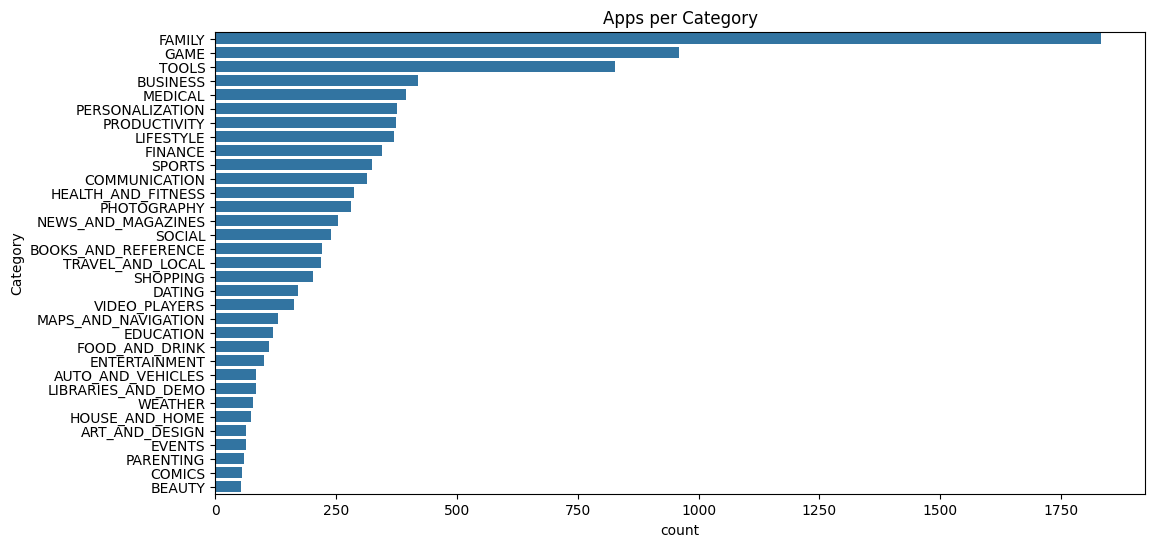

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Category',
    data=apps,
    order=apps['Category'].value_counts().index
)

plt.title("Apps per Category")
plt.show()

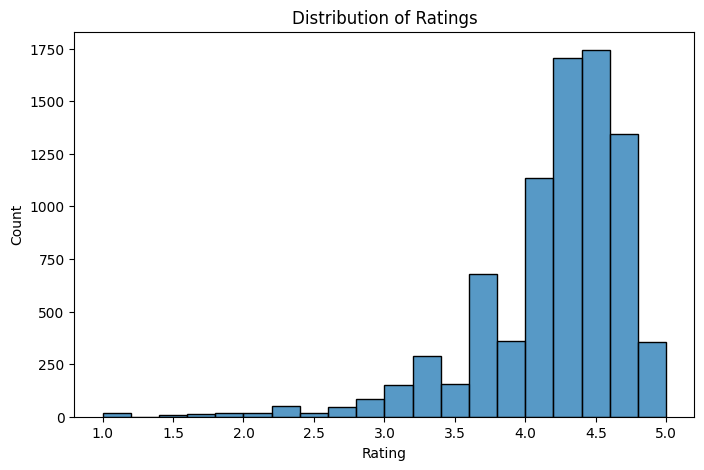

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(apps['Rating'], bins=20)

plt.title("Distribution of Ratings")

plt.show()

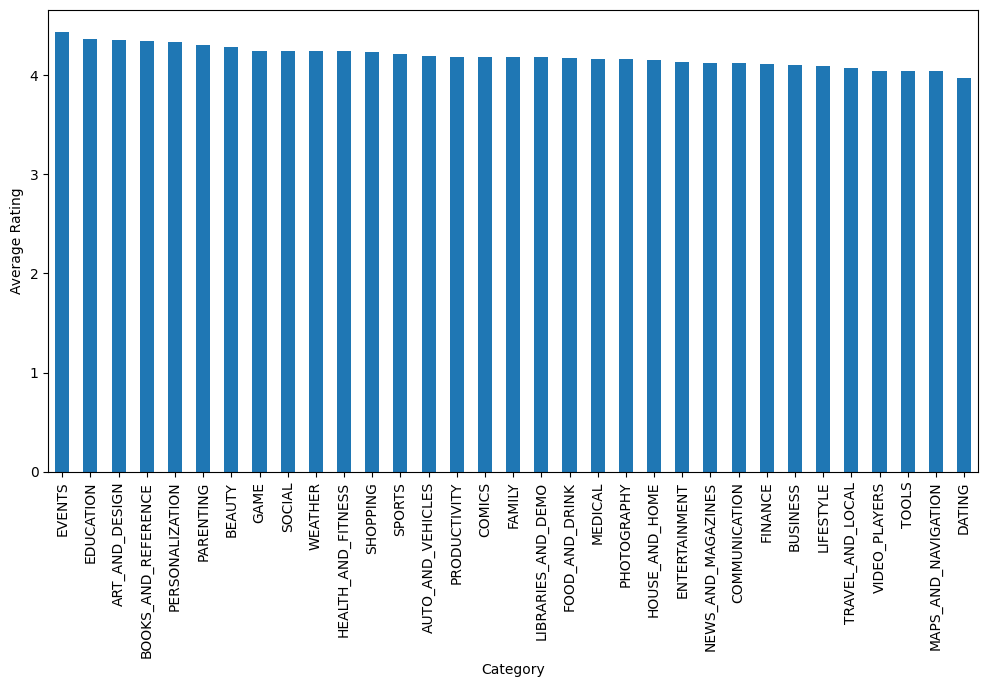

In [24]:
category_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

category_rating.plot(kind='bar', figsize=(12,6))

plt.ylabel("Average Rating")

plt.show()

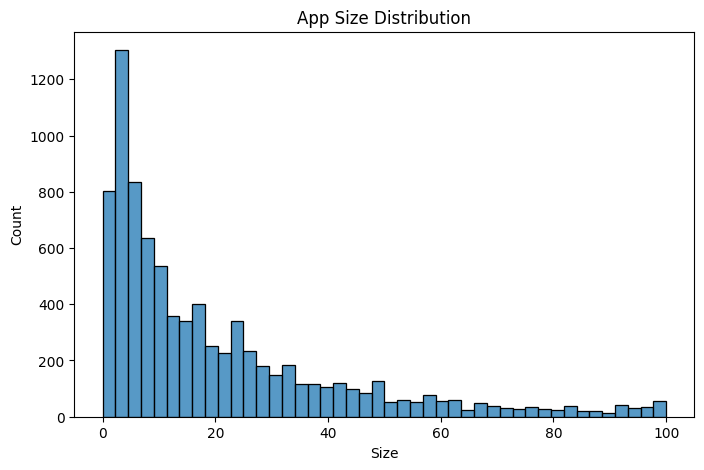

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(apps['Size'])

plt.title("App Size Distribution")

plt.show()

In [26]:
top_apps = apps.sort_values(
    by='Installs',
    ascending=False
)

top_apps[['App','Installs']].head(10)

,App,Installs
342,UC Browser - Fast Download Private & Secure,"500,000,000+"
1410,My Talking Tom,"500,000,000+"
6486,"Security Master - Antivirus, VPN, AppLock, Boo...","500,000,000+"
2527,SHAREit - Transfer & Share,"500,000,000+"
2508,Google Translate,"500,000,000+"
2004,Facebook Lite,"500,000,000+"
4623,Samsung Health,"500,000,000+"
335,Google Duo - High Quality Video Calls,"500,000,000+"
2008,Snapchat,"500,000,000+"
2537,Gboard - the Google Keyboard,"500,000,000+"


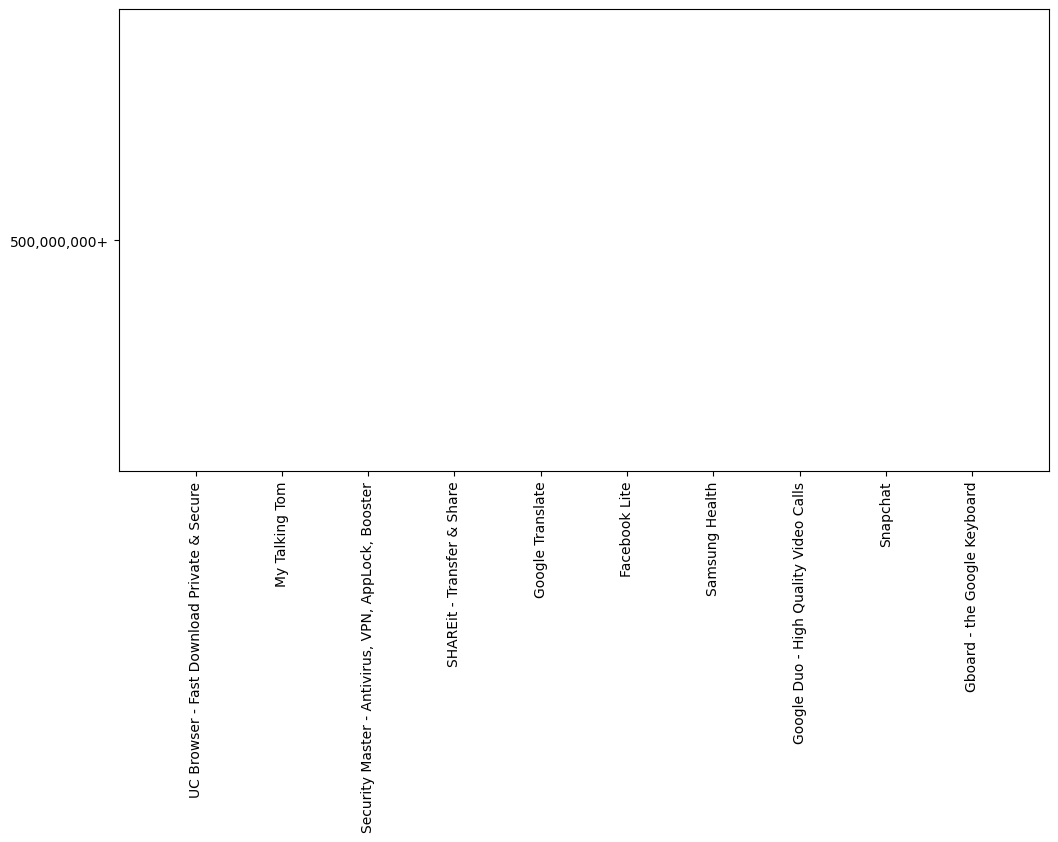

In [29]:
top10 = top_apps.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10['App'], top10['Installs'])

plt.xticks(rotation=90)

plt.show()

In [31]:
apps['Type'].value_counts()

,count
Type,
Free,8903
Paid,756


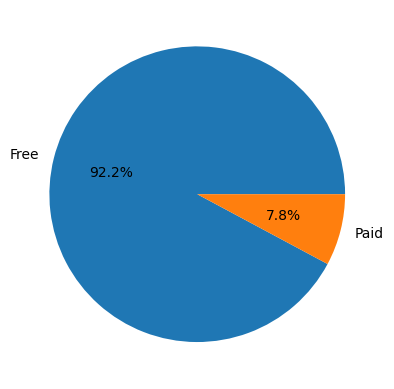

In [32]:
apps['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.show()

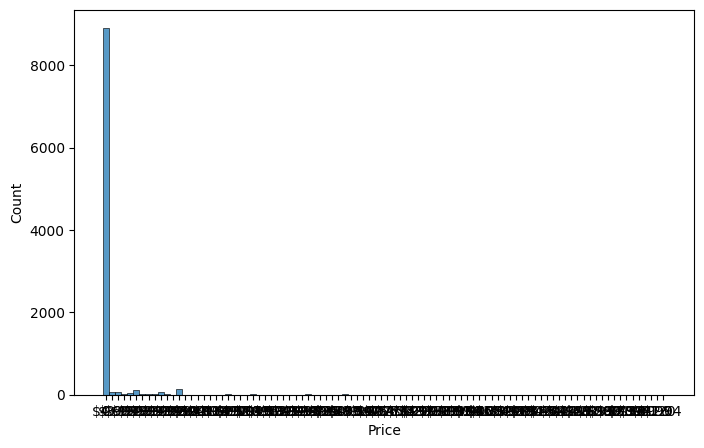

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(apps['Price'])

plt.show()

In [34]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [35]:
reviews['Sentiment'].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5163


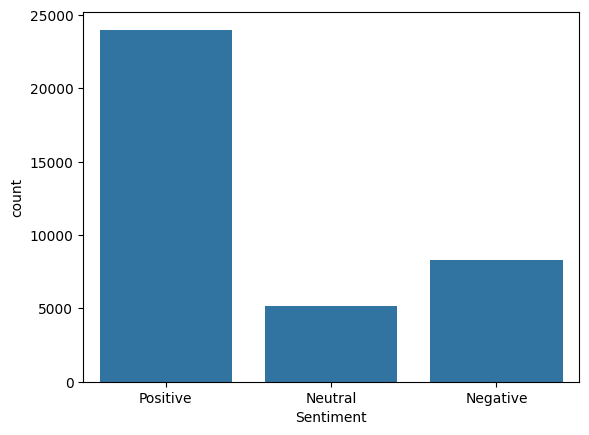

In [36]:
sns.countplot(
    x='Sentiment',
    data=reviews
)

plt.show()

In [37]:
reviews.groupby('Sentiment')['Sentiment_Polarity'].mean()

,Sentiment_Polarity
Sentiment,
Negative,-0.256173
Neutral,0.000000
Positive,0.372402


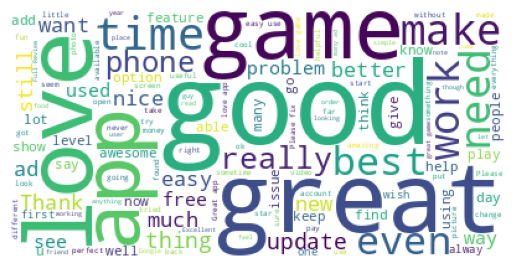

In [38]:
positive = reviews[
    reviews['Sentiment']=="Positive"
]

text = " ".join(
    positive['Translated_Review'].dropna()
)

wordcloud = WordCloud(
    background_color='white'
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

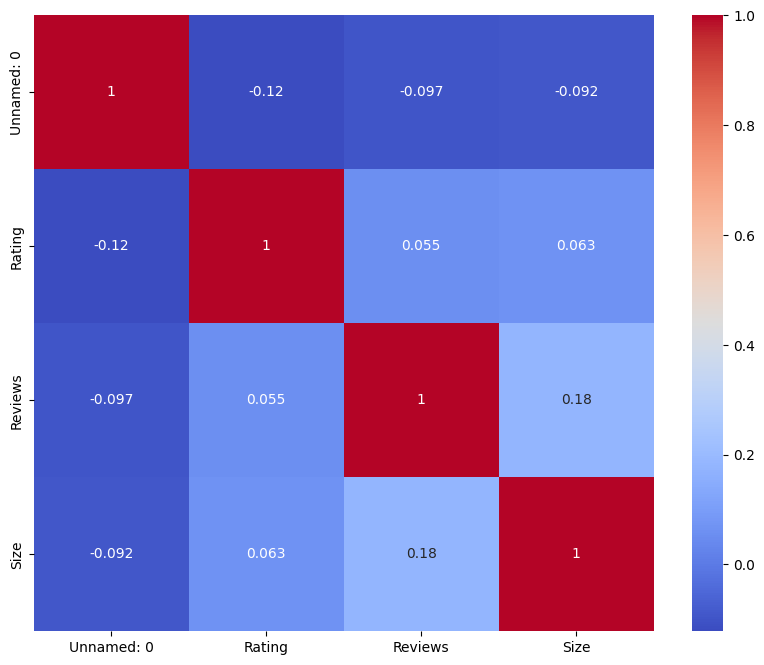

In [39]:
numeric = apps.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Conclusion**
This project analyzed the Google Play Store dataset to understand the Android app market through data cleaning, visualization, and exploratory data analysis. The dataset was prepared by handling missing values, correcting data types, and removing duplicates to ensure accurate analysis. Various visualizations were created to explore app categories, ratings, installs, sizes, pricing, and user sentiments. The analysis revealed that free apps dominate the marketplace, while categories such as Family and Games contain the largest number of applications. Most apps maintain ratings above 4.0, indicating generally positive user experiences, and sentiment analysis further confirmed that positive reviews outweigh negative ones. Overall, this project demonstrates how data analytics and visualization can uncover valuable insights into app market trends, user preferences, and factors influencing app popularity, enabling better decision-making for developers and businesses.